# Solving PDEs via Schrodingerisation with Classiq
This notebook partially replicates results from arXiv:2403.10032v2, solving the heat equation using the methods described in the paper.\
Note: Some modifications were made to allow cleaner delivery in a joint coding session.

## Imports and setup

In [5]:
# Classiq imports
import cmath
import os
from gc import is_finalized
from time import time

import matplotlib.pyplot as plt

# from classiq.execution import execute
import numpy as np
import scipy.sparse as sp
from tqdm import tqdm

from classiq import *

In [6]:
import numpy as np
import scipy.sparse as sp

# Qiskit
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import QFT
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector
from tqdm import tqdm

In [7]:
def print_circuit_details(
    qc,
    qmod=True,
    max_width=None,
    optimization_parameter=OptimizationParameter.NO_OPTIMIZATION,
):
    if qmod:
        qprog = synthesize(
            main,
            constraints=Constraints(
                optimization_parameter=optimization_parameter, max_width=max_width
            ),
        )
        print(
            "Width =",
            qprog.data.width,
            ", Depth =",
            qprog.transpiled_circuit.depth,
            ", CX =",
            qprog.transpiled_circuit.count_ops["cx"],
        )
        show(qprog)
    else:
        t_qc = transpile(qc, basis_gates=["cx", "u"])
        print(f"depth = {t_qc.depth()}")
        print(f"width = {t_qc.width()}")
        print(f"ops = {t_qc.count_ops()}")

## Building Block Circuits

In [8]:
## Wj - helpers


@qfunc
def Bj(j: int, lam: CReal, qbits: QArray[QBit]) -> None:
    H(qbits[j - 1])
    PHASE(-lam, qbits[j - 1])
    repeat(j - 1, lambda i: CX(qbits[j - 1], qbits[i]))


@qfunc
def my_mcrz(theta: CReal, num_qubits: int, qbits: QArray[QBit]) -> None:
    if num_qubits > 1:
        control(qbits[0 : num_qubits - 1], lambda: RZ(theta, qbits[num_qubits - 1]))
    else:
        RZ(theta, qbits[0])


@qfunc
def change_control_condition(num_qubits: int, xgate: CInt, qbits: QArray[QBit]):
    if_(xgate == 1, lambda: repeat(num_qubits - 1, lambda i: X(qbits[i])))

In [9]:
## Wj - Classiq


@qfunc
def Wj_circuit(
    j: int,
    theta: CReal,
    lam: CReal,
    xgate: CInt,
    qbits: QArray[QBit],
):
    within_apply(
        within=lambda: (
            invert(lambda: Bj(j=j, lam=lam, qbits=qbits)),
            change_control_condition(num_qubits=j, xgate=xgate, qbits=qbits),
        ),
        apply=lambda: my_mcrz(theta=theta, num_qubits=j, qbits=qbits),
    )


@qfunc
def main(qbits: Output[QArray[QBit]]) -> None:
    allocate(4, qbits)
    Wj_circuit(4, 0.1, 0.2, 0, qbits)


# print_circuit_details(main)

depth = 27
width = 4
ops = OrderedDict([('cx', 20), ('u', 16)])


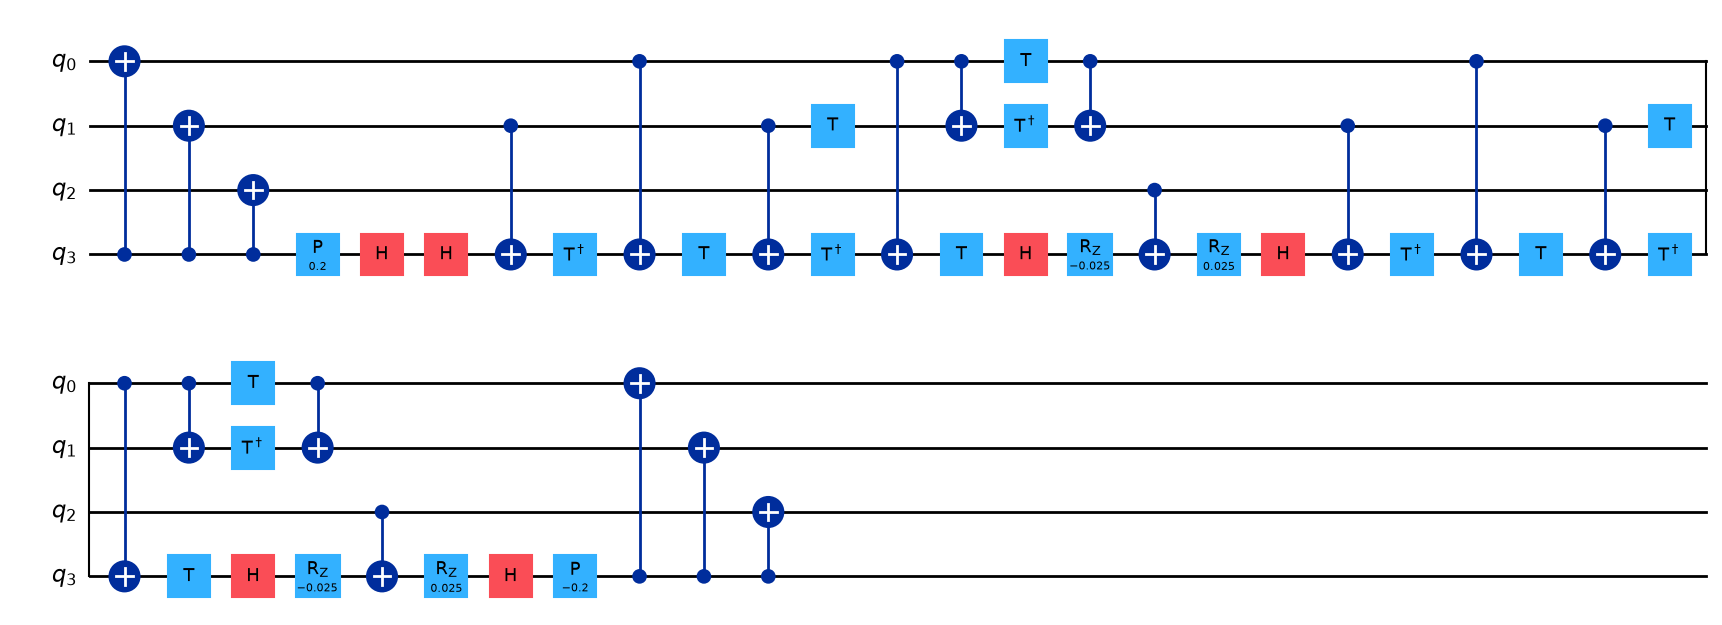

In [10]:
def Wj(j, theta, lam, name="Wj", xgate=False):
    # Wj

    # for the advection equation, set xgate=True to apply extra X gates
    # return U_1^1, U_2^1

    if not xgate:
        name = f" $W_{j}$ "
    qc = QuantumCircuit(j, name=name)

    if j > 1:
        qc.cx(j - 1, range(j - 1))
    if lam != 0:
        qc.p(lam, j - 1)
    qc.h(j - 1)
    if xgate:
        qc.x(range(j - 1))

    # the multicontrolled rz gate
    # it will be decomposed in qiskit
    if j > 1:
        qc.mcrz(theta, range(j - 1), j - 1)
    else:
        qc.rz(theta, j - 1)

    if xgate:
        qc.x(range(j - 1))
    qc.h(j - 1)
    if lam != 0:
        qc.p(-lam, j - 1)
    if j > 1:
        qc.cx(j - 1, range(j - 1))

    return qc


# example
test = Wj(4, 0.1, 0.2)

print_circuit_details(test, qmod=False)
test.draw("mpl")

In [11]:
## V0 Circuit - Classiq


@qfunc
def V0_circuit(theta: float, n: int, qbits: QArray[QBit]):
    phase(theta)
    for j in range(1, n + 1):
        Wj_circuit(j=j, theta=theta, lam=0, xgate=0, qbits=qbits[0:j])


@qfunc
def main(qbits: Output[QArray[QBit]]) -> None:
    allocate(4, qbits)
    V0_circuit(0.1, 4, qbits)


# print_circuit_details(main)

depth = 43
width = 4
ops = OrderedDict([('cx', 30), ('u', 26)])


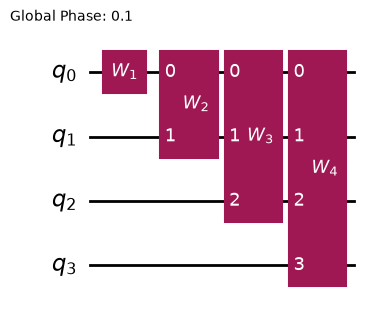

In [12]:
## V0 Circuit - Qiskit


def V0(theta, n):
    # H1_circ for heat equation
    qc = QuantumCircuit(n, global_phase=theta, name="$V_0$")

    # apply wj
    for j in range(1, n + 1):
        qc.append(Wj(j, theta, 0), range(j))
    return qc


# example
test = V0(0.1, 4)
print_circuit_details(test, qmod=False)
test.draw("mpl")

In [13]:
# Controlled V0 Circuit - Classiq


@qfunc
def cV0_circuit(theta: float, n: int, ctrl: QBit, qbits: QArray[QBit]) -> None:
    control(ctrl, lambda: V0_circuit(theta, n, qbits))


@qfunc
def main(ctrl: Output[QBit], qbits: Output[QArray[QBit]]) -> None:
    allocate(ctrl)
    allocate(4, qbits)
    cV0_circuit(0.1, 4, ctrl, qbits)


# print_circuit_details(main)

depth = 414
width = 5
ops = OrderedDict([('u', 312), ('cx', 229)])


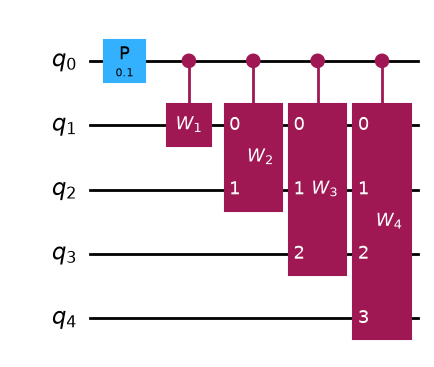

In [14]:
# Controlled V0 Circuit - Qiskit


def cV0(theta, n):
    # cH1_circ for heat equation
    qc = QuantumCircuit(n + 1, name="$cV_0$")
    qc.p(theta, 0)

    # apply controlled wj
    for j in range(1, n + 1):
        cWj = Wj(j, theta, 0).to_gate().control()
        qc.append(cWj, range(j + 1))
    return qc


# example
test = cV0(0.1, 4)
print_circuit_details(test, qmod=False)
test.draw("mpl")

In [15]:
## V_power Circuit - Classiq


@qfunc
def V_power(
    na: CInt, nx: int, theta: float, qx: QArray[QBit], qp: QArray[QBit]
) -> None:
    repeat(na, lambda j: power(2**j, lambda: cV0_circuit(theta, nx, qp[j], qx)))


@qfunc
def main(qx: Output[QArray[QBit]], qp: Output[QArray[QBit]]) -> None:
    allocate(3, qp)
    allocate(4, qx)
    V_power(na=3, nx=4, theta=0.1, qx=qx, qp=qp)


# print_circuit_details(main)

In [16]:
## Single V_heat iteration - Classiq


@qfunc
def V_heat(na: CInt, nx: int, theta: float, qx: QArray[QBit], qp: QArray[QBit]) -> None:
    V_power(na=na, nx=nx, theta=theta, qx=qx, qp=qp)
    power(2 ** (na - 1), lambda: invert(lambda: V0_circuit(theta, nx, qx)))


@qfunc
def main(qx: Output[QArray[QBit]], qp: Output[QArray[QBit]]) -> None:
    allocate(3, qp)
    allocate(4, qx)
    V_heat(na=3, nx=4, theta=0.1, qx=qx, qp=qp)


# print_circuit_details(main)

depth = 3026
width = 7
ops = OrderedDict([('u', 2280), ('cx', 1723)])


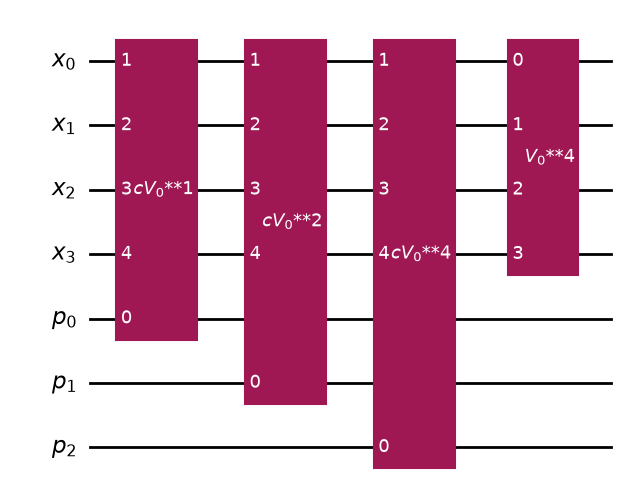

In [17]:
# Single V_heat iteration - Qiskit


def qiskit_one_step(theta, R, na, nx):
    rx = QuantumRegister(nx, name="x")
    ra = QuantumRegister(na, name="p")
    qc = QuantumCircuit(rx, ra)

    cH1 = cV0(theta / R, nx)
    iH1 = V0(-theta / R, nx)

    for j in range(na):
        # repeat controlled H1 for 2**j times
        qc.append(cH1.repeat(2**j), [ra[j]] + rx[:])

    # repeat inverse H1 for 2**(na-1) times
    qc.append(iH1.repeat(2 ** (na - 1)), rx[:])
    return qc


test = qiskit_one_step(0.1, 4, 3, 4)
print_circuit_details(test, qmod=False)
test.draw("mpl")

In [18]:
## Multiple heat time steps - Classiq


@qfunc
def heat(
    Nt: CInt, na: CInt, nx: int, theta: float, qx: QArray[QBit], qp: QArray[QBit]
) -> None:
    power(Nt, lambda: V_heat(na=na, nx=nx, theta=theta, qx=qx, qp=qp))

## Full quantum heat equation solver

In [19]:
# =========================
# Classical reference code
# =========================


def schro_classical(u0, A, R=4, na=3, T=3):
    A1, A2 = (A + A.T.conjugate()) / 2, -1j * (A - A.T.conjugate()) / 2
    Nx, Na = A1.shape[0], 2**na
    p = np.arange(-R * np.pi, R * np.pi, step=2 * R * np.pi / 2**na)
    fp, up = np.exp(-np.abs(p)), u0 * np.exp(-np.abs(p))[:, None]
    eta = np.arange(Na)
    eta[2 ** (na - 1) :] -= Na
    diag_eta = sp.csc_matrix((eta / R, (range(Na), range(Na))), shape=[Na, Na])
    ueta = np.fft.fft(up, axis=0).flatten()
    H = sp.csc_matrix(sp.kron(diag_eta, A1) + sp.kron(sp.eye(Na), A2))
    ueta = sp.linalg.expm_multiply(1j * H * T, ueta)
    return np.real(np.fft.ifft(ueta.reshape(Na, Nx), axis=0)[2 ** (na - 1)])


def matrix_exponential(u0, A, T=3):
    return sp.linalg.expm_multiply(A * T, u0)


def initial_heat(nx=4, L=2**4 + 1):
    dx = L / (2**nx + 1)
    x = np.arange(dx, L, step=dx)
    return x, np.sin(np.pi * x / L), dx


def exact_heat(x, L, T, a=1):
    return np.sin(np.pi * x / L) * np.exp(-a * np.pi**2 / L**2 * T)

In [20]:
# =========================================
# Classical functions to parse statevectors
# =========================================


def get_magnitudes_phases(result) -> tuple[list[complex], list[complex]]:
    df = result.dataframe.copy()
    df = df.sort_values(by=["qp", "qx"]).reset_index(drop=True)
    magnitudes = [float(magnitude) for magnitude in df["magnitude"]]
    phases = [np.pi * float(str(phase)[:-1]) for phase in df["phase"]]
    return magnitudes, phases


def global_phase_align(u_slice):
    """
    Remove a global phase so the largest-magnitude component is real-positive.
    This fixes the 'u_slice is mostly imaginary' bug before taking np.real().
    """
    if u_slice is None or len(u_slice) == 0:
        return u_slice
    idx = int(np.argmax(np.abs(u_slice)))
    if np.abs(u_slice[idx]) > 0:
        u_slice = u_slice * np.exp(-1j * np.angle(u_slice[idx]))
    return u_slice


def identity_on_first_nx(nx: int):
    term = Pauli.I(0)
    for q in range(1, nx):
        term = term * Pauli.I(q)
    return term


def build_projected_observable_msb_last(nx: int, na: int, obs_term):
    msb = nx + na - 1
    rest = list(range(nx, nx + na - 1))  # all p qubits except msb

    # Start with one_op on msb as list of single-term ops
    terms = [0.5 * Pauli.I(msb), -0.5 * Pauli.Z(msb)]

    # Tensor with zero_op on each remaining p qubit, distributing into single terms
    for q in rest:
        new_terms = []
        for t in terms:
            new_terms.append(0.5 * (t * Pauli.I(q)))
            new_terms.append(0.5 * (t * Pauli.Z(q)))
        terms = new_terms

    # Multiply obs_term into EACH single term (safe)
    terms = [t * obs_term for t in terms]

    # Sum all terms (no int/float start)
    observable = terms[0]
    for t in terms[1:]:
        observable = observable + t

    return observable

In [21]:
# =========================
# Quantum (Classiq) solver
# =========================


def create_main(
    na: int,
    nx: int,
    R: int,
    theta: float,
    fp: list,
    u0: list,
    is_start: bool = False,
    magnitudes: CArray[CReal] = None,
    phases: list[float] = None,
    is_final: bool = False,
    time_steps_per_run: int = 1,
    obs=None,
):

    @qfunc
    def prepare_initial_states(qx: Output[QArray[nx]], qp: Output[QArray[na]]):
        fp_norm = fp / np.linalg.norm(fp)
        u0_norm = u0 / np.linalg.norm(u0)
        prepare_amplitudes(fp_norm.tolist(), 0, qp)
        prepare_amplitudes(u0_norm.tolist(), 0, qx)

    @qfunc
    def basis_change(qp: QArray[na]):
        qft(qp)
        X(qp[na - 1])

    @qfunc
    def invert_basis_change(qp: QArray[na]):
        invert(lambda: basis_change(qp))

    @qfunc
    def prepare_previous_states(qx: Output[QArray[nx]], qp: Output[QArray[na]]):
        temp = QArray()
        allocate(na + nx, temp)
        inplace_prepare_complex_amplitudes(magnitudes, phases, temp)
        bind(temp, [qx, qp])

    @qfunc
    def main(qx: Output[QNum[nx]], qp: Output[QNum[na]]) -> None:
        if is_start:
            prepare_initial_states(qx=qx, qp=qp)
            basis_change(qp=qp)
        else:
            prepare_previous_states(qx=qx, qp=qp)
            if obs is not None:
                basis_change(qp=qp)

        heat(time_steps_per_run, na, nx, theta / R, qx, qp)
        if obs is not None:
            invert_basis_change(qp=qp)

        if is_final and obs is None:
            invert_basis_change(qp=qp)

    return main


## Full quantum program (including statevector parsing)


def schro_classiq(
    u0,
    theta,
    R=4,
    na=3,
    nx=4,
    Nt=1,
    return_parsed_sv=False,
    debug=False,
    obs=None,
    E=None,
    time_steps_per_run=1,
):
    dp = 2 * R * np.pi / 2**na
    p = np.arange(-R * np.pi, R * np.pi, step=2 * R * np.pi / 2**na)
    fp = np.exp(-np.abs(p))
    norm = np.linalg.norm(u0) * np.linalg.norm(fp)
    norm1 = np.linalg.norm(fp[2 ** (na - 1) :])  # norm of p>=0
    k_star = 2 ** (na - 1)

    # construct the observable
    if obs is not None:
        values = np.zeros((2, Nt))
        observable = build_projected_observable_msb_last(nx=nx, na=na, obs_term=obs)
    else:
        values = None

    backend_preferences = ClassiqBackendPreferences(
        backend_name="simulator_statevector"
    )
    exec_prefs = ExecutionPreferences(
        num_shots=1, backend_preferences=backend_preferences
    )
    prefs = Preferences(
        debug_mode=False,
        timeout_seconds=7200,
        optimization_timeout_seconds=600,
    )  #

    magnitudes = None
    phases = None
    Nt = Nt // time_steps_per_run
    print(f"New Nt is {Nt}")
    for i in range(Nt):
        print(f"\n=== Time step {i+1}/{Nt} ===")
        is_start = i == 0
        is_final = i == (Nt - 1)

        main_current_iteration = create_main(
            na=na,
            nx=nx,
            R=R,
            theta=theta,
            fp=fp,
            u0=u0,
            magnitudes=magnitudes,
            phases=phases,
            is_start=is_start,
            is_final=is_final,
            time_steps_per_run=time_steps_per_run,
            obs=obs,
        )
        qmod = create_model(
            main_current_iteration,
            preferences=prefs,
            execution_preferences=exec_prefs,
            constraints=Constraints(max_width=na + nx),
        )

        write_qmod(
            qmod,
            "heat_eq_schrodingerisation",
            symbolic_only=False,
        )

        start = time()
        qprog = synthesize(qmod)

        if obs is not None:
            exec_prefs_1 = ExecutionPreferences(num_shots=10000)
            prefs = Preferences(
                debug_mode=False,
                timeout_seconds=7200,
                optimization_timeout_seconds=600,
            )
            # -------------------------
            # Session 1: projected EV p=0
            # -------------------------
            with ExecutionSession(qprog, execution_preferences=exec_prefs_1) as es1:
                print("Executing obs - estimate")
                ev_res = es1.observe(observable)
                ev = ev_res.value
                ev_real = float(np.real(ev))
                values[0, i] = ev_real * norm**2
                print(f"Execution time={np.round(time()-start)} seconds")

            # -------------------------
            # Session 2: probability p>=0
            # -------------------------
            exec_prefs_2 = ExecutionPreferences(
                num_shots=10000, backend_preferences=backend_preferences
            )
            msb = nx + na - 1
            with ExecutionSession(qprog, execution_preferences=exec_prefs_2) as es2:
                print("Executing obs - sample")
                res = es2.sample()

                df = res.dataframe

                # df -> MSB by threshold
                p_msb_thr_df = df.loc[df.qp >= k_star, "probability"].sum()

                print(p_msb_thr_df)

                values[1, i] = p_msb_thr_df * norm**2 / norm1**2
                magnitudes, phases = get_magnitudes_phases(res)
                print(f"Execution time={np.round(time()-start)} seconds")

        if is_start:
            pass
            # show(qprog)

        if is_final:
            # show(qprog)
            break

        if not obs:
            with ExecutionSession(qprog, execution_preferences=exec_prefs) as es:
                print("Executing")
                start = time()
                results = es.sample()
                print(f"Execution time={time()-start}")
                magnitudes, phases = get_magnitudes_phases(results)

    with ExecutionSession(qprog, execution_preferences=exec_prefs) as es:
        print("Executing")
        start = time()
        results = es.sample()
        print(f"Execution time={time()-start}")

    df = results.dataframe.sort_values("qx").reset_index(drop=True)
    state_result_1 = df[(df.qp == k_star)].amplitude.values
    u_slice = global_phase_align(state_result_1)
    u_raw = np.real(u_slice) * norm
    return u_raw, qprog, values

In [22]:
# ===================================
# Run + Plot (solution at final time)
# ===================================


def run(na=5, R=4, T=1, dt=0.005, debug=False, measure=False, time_steps_per_run=-1):
    nx, L = 4, (2**4 + 1)
    a = L / np.pi**2

    Nt = int(T / dt)
    time_steps_per_run = Nt if time_steps_per_run == -1 else time_steps_per_run

    t = np.arange(dt, T + dt, step=dt)

    x, u0, dx = initial_heat(nx=nx, L=L)
    A = sp.csc_matrix(
        (-2 * np.eye(2**nx) + np.eye(2**nx, k=1) + np.eye(2**nx, k=-1)) * a / dx**2
    )
    theta, exact_fun = -2 * a / dx**2 * dt, exact_heat

    u_classical = schro_classical(u0=u0, A=A, R=R, na=na, T=Nt * dt)
    u_matrix = matrix_exponential(u0=u0, A=A, T=Nt * dt)
    u_exact = exact_fun(x=x, L=L, T=Nt * dt, a=a)

    if measure:
        # measure at each time step
        print("Running the classical simulation")
        obs = identity_on_first_nx(nx)
        values_classical, values_matrix, values_exact = (
            np.zeros(Nt),
            np.zeros(Nt),
            np.zeros(Nt),
        )

        for i in range(1, Nt + 1):
            u_classical = schro_classical(u0=u0, A=A, R=R, na=na, T=i * dt)
            u_matrix = matrix_exponential(u0=u0, A=A, T=i * dt)
            u_exact = exact_fun(x=x, L=L, T=i * dt, a=a)

            values_classical[i - 1] = np.linalg.norm(u_classical) ** 2
            values_matrix[i - 1] = np.linalg.norm(u_matrix) ** 2
            values_exact[i - 1] = np.linalg.norm(u_exact) ** 2
    else:
        # only check solutions at the final time
        obs, values_classical, values_matrix, values_exact = None, None, None, None
        u_classical = schro_classical(u0=u0, A=A, R=R, na=na, T=Nt * dt)
        u_matrix = matrix_exponential(u0=u0, A=A, T=Nt * dt)
        u_exact = exact_fun(x=x, L=L, T=Nt * dt, a=a)

    print("Running quantum simulation")

    u_raw, qprog, values_q = schro_classiq(
        u0,
        theta,
        R=R,
        nx=nx,
        na=na,
        Nt=Nt,
        debug=debug,
        obs=obs,
        E=values_classical,
        time_steps_per_run=1 if obs else time_steps_per_run,
    )

    # Stack results: [quantum_raw, classical_schro, matrix, exact]
    U = np.concatenate(
        (u_raw[None, :], u_classical[None, :], u_matrix[None, :], u_exact[None, :]),
        axis=0,
    )
    dist = np.linalg.norm(u_raw - u_classical)

    if measure:
        values = np.vstack(
            [
                values_q[0],  # 0: Proposed, p=0
                values_q[1],  # 1: Proposed, p>=0
                values_classical,  # 2: Classical Schro
                values_matrix,  # 3: Matrix operator
                values_exact,  # 4: Exact
            ]
        )
    else:
        values = None

    return (x, t, dt, na, T), qprog, U, values

In [23]:
## Plot the solution for a specific np (k)


def plot_solution_single(
    k=0,
    R=4,
    T=5,
    dt=0.5,
    ylim=(0, 1.2),
    debug=False,
    figsize=(8, 6),
    measure=False,
    time_steps_per_run=-1,
):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    na = k * 2 + 3
    # ========================
    # Run quantum program
    # ========================
    meta, qprog, U, _ = run(
        na=na,
        R=R,
        T=T,
        dt=dt,
        debug=debug,
        measure=measure,
        time_steps_per_run=time_steps_per_run,
    )
    # ========================
    x = meta[0]

    # U indices:
    # 0 = quantum raw
    # 1 = classical schro
    # 2 = matrix
    # 3 = exact
    q_quantum = U[0].copy()
    q_classic = U[1].copy()

    # sign-align quantum to classical schro (NOT exact)
    if float(np.dot(q_quantum, q_classic)) < 0:
        q_quantum = -q_quantum

    ax.plot(x, U[3], "red", label="Exact")
    ax.plot(x, U[2], "blue", linestyle="--", label="Matrix operator")
    ax.plot(
        x,
        U[1],
        color="black",
        linestyle="--",
        marker="s",
        label="Classical schro",
    )
    ax.plot(x, q_quantum, "d-", label=f"Quantum raw (dt={dt})")

    ax.set_xlabel("x")
    ax.set_ylim(list(ylim))
    ax.set_title(f"T = {T}    $n_p$ = {na}")

    ax.legend(prop={"size": 12})
    plt.tight_layout()
    plt.show()

In [24]:
def plot_norm(na=7, R=4, T=5, dt=0.005, debug=False):
    meta, qprog, U, values = run(na=na, R=R, T=T, dt=dt, debug=debug, measure=True)
    t = meta[1]

    plt.figure()
    plt.plot(t, values[4], "red")
    plt.plot(t, values[3], "blue", linestyle="--")
    plt.plot(t, values[2], "black")
    plt.plot(t, values[1], "mediumseagreen", linestyle="dotted")
    plt.plot(t, values[0], "orange", linestyle="dotted")

    plt.legend(
        [
            "Exact",
            "Matrix operator",
            f"Classical Schro, $n_p$={meta[3]}",
            f"Proposed, $n_p$={meta[3]}, $p\\geq0$",
            f"Proposed, $n_p$={meta[3]}, $p=0$",
        ]
    )
    plt.xlabel("T")
    plt.title(f"Heat, $\\|u\\|^2$")
    # plt.savefig(f"./-norm.pdf", dpi=600, format="pdf", bbox_inches="tight")
    plt.show()

Running quantum simulation
New Nt is 5

=== Time step 1/5 ===
Executing
Execution time=5.32620096206665

=== Time step 2/5 ===
Executing
Execution time=10.601999998092651

=== Time step 3/5 ===
Executing
Execution time=9.659824848175049

=== Time step 4/5 ===
Executing
Execution time=9.64689302444458

=== Time step 5/5 ===
Executing
Execution time=10.02751088142395


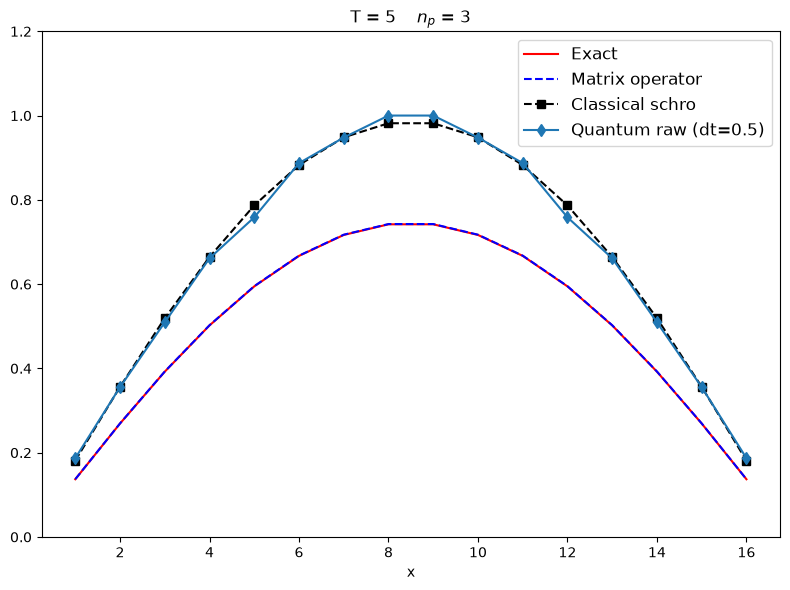

In [26]:
plot_solution_single(k=0, T=5, dt=0.5, ylim=[0, 1.2], debug=False, time_steps_per_run=2)

Running the classical simulation
Running quantum simulation
New Nt is 100

=== Time step 1/100 ===
Executing obs - estimate
Execution time=15.0 seconds
Executing obs - sample
0.8263560295577519
Execution time=21.0 seconds

=== Time step 2/100 ===
Executing obs - estimate
Execution time=57.0 seconds
Executing obs - sample
0.824461308760373
Execution time=80.0 seconds

=== Time step 3/100 ===
Executing obs - estimate
Execution time=53.0 seconds
Executing obs - sample
0.8244705128107603
Execution time=77.0 seconds

=== Time step 4/100 ===
Executing obs - estimate
Execution time=51.0 seconds
Executing obs - sample
0.8244596145047609
Execution time=76.0 seconds

=== Time step 5/100 ===
Executing obs - estimate
Execution time=52.0 seconds
Executing obs - sample
0.824457897951893
Execution time=77.0 seconds

=== Time step 6/100 ===
Executing obs - estimate
Execution time=52.0 seconds
Executing obs - sample
0.8244563646156883
Execution time=76.0 seconds

=== Time step 7/100 ===
Executing obs -

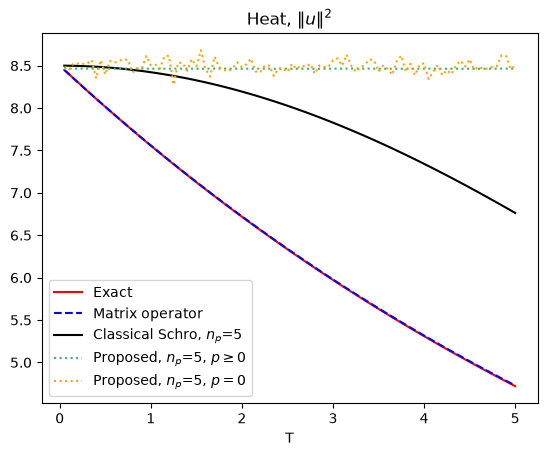

In [31]:
plot_norm(na=5, T=5, dt=0.05)